In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
from pathlib import Path
from typing import Literal

from hcc_multimodal.baselines.data import add_rfs_columns
from hcc_multimodal.baselines.transforms import DataType
from hcc_multimodal.baselines.evaluation import (
    run_cv_experiment,
    plot_cv_results,
    DeseqCPMSelector,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from itertools import product

In [3]:
RANDOM_STATE = 42
RNA_COUNT_FILTER = 15
RNA_COUNT_FILTER_MIN_SAMPLES = 5
DESEQ_PVALUE = 0.1
DESEQ_MIN_FEATURES = 20
RFS_YEARS = [1, 2]
CV_N_FOLDS = 3

SELECTOR: Literal["deseq", "sklearn_kbest"] = "sklearn_kbest"
KBEST: int = 80

# Read data

In [4]:
ROOT = Path().resolve().parents[1]


clinical_data = pd.read_csv(
    ROOT
    / "data"
    / "Clinical"
    / "2025_Nov_18_ICL_Resection_Clinical_Outcome_soramic_format.csv"
).dropna(how="all")

rna_data = pd.read_csv(
    ROOT / "data" / "RNA_seq" / "Matrix_output_radiology_only.csv"
).dropna(how="all")

In [5]:
columns = rna_data["Gene Symbol"]
rna_data = rna_data.T.iloc[2:, :]
rna_data.columns = columns.values

# Drop columns with NaN gene symbols and deduplicate gene names
rna_data = rna_data.loc[:, ~pd.isnull(rna_data.columns)]
rna_data = rna_data.loc[:, ~rna_data.columns.duplicated()]

# Convert expression values to numeric, make SID an integer column
rna_data = rna_data.apply(pd.to_numeric, errors="coerce")
rna_data.index = rna_data.index.astype(int)
rna_data = rna_data.rename_axis("SID").reset_index()

print(f"RNA data shape (patients × genes): {rna_data.shape}")
rna_data.head()

RNA data shape (patients × genes): (60, 50987)


,SID,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,...,AC134980.5,AL691520.1,AC139491.7,AC021097.2,AL590381.1,AC003043.2,AC135068.11,AL356417.3,AC104389.6,AP000646.1
0,39,0,0,0,0,0,0,245,0,0,...,0,0,0,0,0,0,0,0,0,0
1,31,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,66,150,0,153,0,0,0,828,63,0,...,0,0,0,0,0,0,0,0,0,0
3,33,139,0,0,0,0,0,3206,0,224,...,0,0,0,0,0,1,0,3,0,0
4,132,0,0,0,0,37,2,985,0,236,...,0,0,0,0,0,1,0,0,0,0


# RFS column

In [6]:
clinical_data = add_rfs_columns(clinical_data)
clinical_data[["RFS_central", "RFS_central_event", "rfs_1year", "rfs_2year"]].head(10)

,RFS_central,RFS_central_event,rfs_1year,rfs_2year
0,31.791781,0.0,0.0,0.0
1,30.279452,1.0,0.0,0.0
2,40.865753,1.0,0.0,0.0
3,14.301370,1.0,0.0,1.0
4,24.756164,1.0,0.0,0.0
5,9.600000,1.0,1.0,1.0
6,8.054795,1.0,1.0,1.0
7,6.936986,1.0,1.0,1.0
8,49.643836,1.0,0.0,0.0
9,11.441096,1.0,1.0,1.0


In [7]:
clinical_data[["RFS_central", "RFS_central_event", "rfs_1year", "rfs_2year"]].tail(10)

,RFS_central,RFS_central_event,rfs_1year,rfs_2year
59,52.734247,0.0,0.0,0.0
60,63.813699,1.0,0.0,0.0
61,75.879452,0.0,0.0,0.0
62,2.367123,0.0,NaN,NaN
63,7.791781,1.0,1.0,1.0
64,5.983562,1.0,1.0,1.0
65,5.786301,1.0,1.0,1.0
66,132.526027,1.0,0.0,0.0
67,27.320548,1.0,0.0,0.0
68,97.347945,0.0,0.0,0.0


In [8]:
print(clinical_data["rfs_1year"].value_counts(dropna=False))
print(clinical_data["rfs_2year"].value_counts(dropna=False))

rfs_1year
0.0    43
1.0    21
NaN     5
Name: count, dtype: int64
rfs_2year
0.0    33
1.0    29
NaN     7
Name: count, dtype: int64


In [9]:
rna_count = rna_data.drop(columns=["SID"])
rna_count.index = rna_data["SID"]
print("Before filtering:", rna_count.shape[1])
rna_count_flt = rna_count.loc[
    :, (rna_count >= RNA_COUNT_FILTER).sum(axis=0) >= RNA_COUNT_FILTER_MIN_SAMPLES
]
print("After filtering:", rna_count_flt.shape[1])
rna_count_flt.head()

Before filtering: 50986
After filtering: 27991


,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,NFYA,...,AC087564.1,FO393400.1,AC104162.2,AL033530.1,GABPB1-IT1,BX571818.1,AC093827.5,AC139491.7,AC135068.11,AL356417.3
SID,,,,,,,,,,,,,,,,,,,,,
39,0,0,0,0,0,0,245,0,0,0,...,0,0,0,0,0,0,0,0,0,0
31,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
66,150,0,153,0,0,0,828,63,0,82,...,0,0,123,0,0,0,0,0,0,0
33,139,0,0,0,0,0,3206,0,224,0,...,98,0,15,0,0,0,64,0,0,3
132,0,0,0,0,37,2,985,0,236,0,...,0,0,0,0,0,0,0,0,0,0


In [10]:
rna_rfs = rna_count_flt.merge(
    clinical_data[["SID", "rfs_1year", "rfs_2year"]], on="SID"
)
rna_rfs = rna_rfs.set_index("SID")
rna_rfs.head()

,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,NFYA,...,AC104162.2,AL033530.1,GABPB1-IT1,BX571818.1,AC093827.5,AC139491.7,AC135068.11,AL356417.3,rfs_1year,rfs_2year
SID,,,,,,,,,,,,,,,,,,,,,
39,0,0,0,0,0,0,245,0,0,0,...,0,0,0,0,0,0,0,0,0.0,0.0
31,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0.0,1.0
66,150,0,153,0,0,0,828,63,0,82,...,123,0,0,0,0,0,0,0,NaN,NaN
33,139,0,0,0,0,0,3206,0,224,0,...,15,0,0,0,64,0,0,3,0.0,1.0
132,0,0,0,0,37,2,985,0,236,0,...,0,0,0,0,0,0,0,0,NaN,NaN


# CV experiments

In [11]:
if SELECTOR == "deseq":
    selector = DeseqCPMSelector(pvalue=DESEQ_PVALUE, min_features=DESEQ_MIN_FEATURES)
elif SELECTOR == "sklearn_kbest":
    selector = SelectKBest(f_classif, k=KBEST)
else:
    raise ValueError(f"Unknown SELECTOR: {SELECTOR!r}")

In [12]:
if SELECTOR == "deseq":
    OUTPUT_DIR = ROOT / "notebooks" / "baselines" / f"{CV_N_FOLDS}_folds"
else:
    OUTPUT_DIR = ROOT / "notebooks" / "baselines" / f"kbest_{CV_N_FOLDS}_folds"
OUTPUT_DIR.mkdir(exist_ok=True)

[RFS 1 year - RNA-seq]  n=56  positives=19  features=27991


/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [23517 27801] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [26012] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [23517 27801] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [26012] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [23517 27801] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [26012] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [23517 27801] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [26012] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


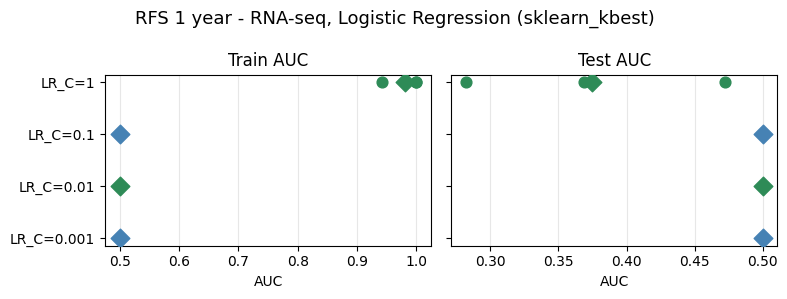

[RFS 1 year - RNA-seq]  n=56  positives=19  features=27991


/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [23517 27801] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [26012] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [23517 27801] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [26012] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


...

/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [26012] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [23517 27801] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [26012] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [23517 27801] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [26012] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


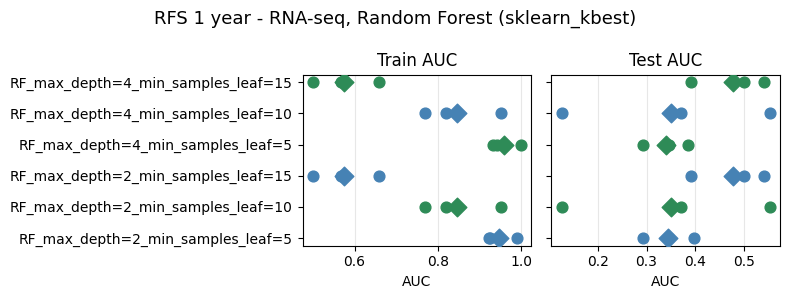

[RFS 2 year - RNA-seq]  n=54  positives=26  features=27991


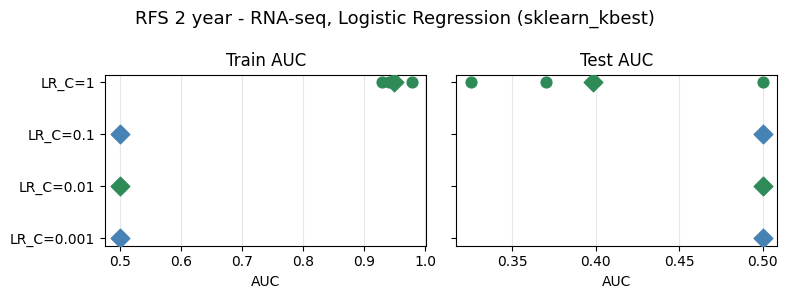

[RFS 2 year - RNA-seq]  n=54  positives=26  features=27991


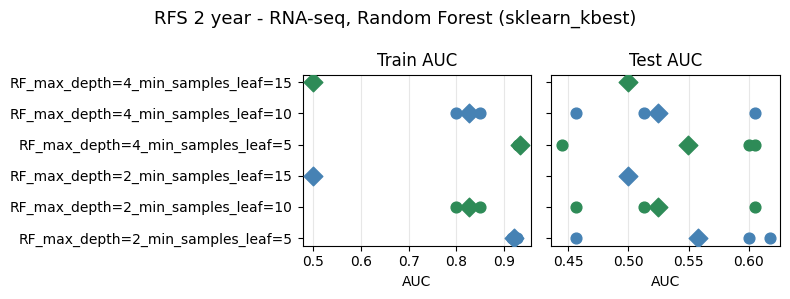

,experiment,model,AUC mean,AUC std,Accuracy mean,Accuracy std
0,RFS 1 year - RNA-seq,LR_C=0.001,0.500,0.000,0.661,0.022
1,RFS 1 year - RNA-seq,LR_C=0.01,0.500,0.000,0.661,0.022
2,RFS 1 year - RNA-seq,LR_C=0.1,0.500,0.000,0.661,0.022
3,RFS 1 year - RNA-seq,LR_C=1,0.374,0.078,0.535,0.033
4,RFS 1 year - RNA-seq,RF_max_depth=2_min_samples_leaf=5,0.345,0.043,0.625,0.086
5,RFS 1 year - RNA-seq,RF_max_depth=2_min_samples_leaf=10,0.350,0.176,0.661,0.022
6,RFS 1 year - RNA-seq,RF_max_depth=2_min_samples_leaf=15,0.478,0.064,0.661,0.022
7,RFS 1 year - RNA-seq,RF_max_depth=4_min_samples_leaf=5,0.341,0.038,0.624,0.081
8,RFS 1 year - RNA-seq,RF_max_depth=4_min_samples_leaf=10,0.350,0.176,0.661,0.022
9,RFS 1 year - RNA-seq,RF_max_depth=4_min_samples_leaf=15,0.478,0.064,0.661,0.022


In [13]:
X = rna_rfs.drop(columns=["rfs_1year", "rfs_2year"])
x_columns = {col: DataType.CONTINUOUS for col in X}

selector_first = SELECTOR == "deseq"

all_records = []

for RFS_YEAR in RFS_YEARS:
    y = rna_rfs[f"rfs_{RFS_YEAR}year"]
    EXPERIMENT_LABEL = f"RFS {RFS_YEAR} year - RNA-seq"

    # --- Logistic Regression ---
    MODELS_LR = {
        f"LR_C={c}": LogisticRegression(
            solver="liblinear",
            l1_ratio=1.0,
            C=c,
            max_iter=1000,
            random_state=RANDOM_STATE,
        )
        for c in [0.001, 0.01, 0.1, 1]
    }
    records_lr, fold_records_lr = run_cv_experiment(
        X,
        y,
        x_columns,
        EXPERIMENT_LABEL,
        feature_selector=selector,
        selector_first=selector_first,
        models=MODELS_LR,
        n_splits=CV_N_FOLDS,
    )
    plot_cv_results(
        fold_records_lr,
        title=f"{EXPERIMENT_LABEL}, Logistic Regression ({SELECTOR})",
        save_path=OUTPUT_DIR / f"rfs_{RFS_YEAR}y_lr.png",
    )

    # --- Random Forest ---
    MODELS_RF = {
        f"RF_max_depth={d}_min_samples_leaf={m}": RandomForestClassifier(
            max_depth=d, min_samples_leaf=m, random_state=RANDOM_STATE
        )
        for d, m in product([2, 4], [5, 10, 15])
    }
    records_rf, fold_records_rf = run_cv_experiment(
        X,
        y,
        x_columns,
        EXPERIMENT_LABEL,
        feature_selector=selector,
        selector_first=selector_first,
        models=MODELS_RF,
        n_splits=CV_N_FOLDS,
    )
    plot_cv_results(
        fold_records_rf,
        title=f"{EXPERIMENT_LABEL}, Random Forest ({SELECTOR})",
        save_path=OUTPUT_DIR / f"rfs_{RFS_YEAR}y_rf.png",
    )

    # Save selected features (one CSV per model type per year, all folds combined)
    for fold_records, model_type in [(fold_records_lr, "lr"), (fold_records_rf, "rf")]:
        feats = []
        for _, row in fold_records.iterrows():
            if row["selected_features"] is not None:
                df = row["selected_features"].copy()
                df["fold"] = row["fold"]
                df["model"] = row["model"]
                feats.append(df)
        if feats:
            (
                pd.concat(feats, ignore_index=True).to_csv(
                    OUTPUT_DIR / f"rfs_{RFS_YEAR}y_{model_type}_selected_features.csv",
                    index=False,
                )
            )

    all_records.extend([records_lr, records_rf])

summary = pd.concat(all_records, ignore_index=True)
display(summary)